# In-Code (Output-Time) PCA SED Coefficients — Verification & Comparison (Millennium-II)

This notebook:
1. Reads the PCA coefficients that L-GALAXIES writes **in-code at snapshot-output time** (`COMP_PCA_COEFFICIENTS`) from the binary output file. These are computed by convolving each galaxy's stored star-formation history with the PCA(age, Z) grid — the same code path as L-GALAXIES' post-processed magnitudes (`code/pca_sed.c` → `save.c`, next to `post_process_spec_mags`).
2. Reconstructs galaxy SEDs from these coefficients and computes synthetic SDSS *ugriz* AB magnitudes.
3. Compares the reconstructed magnitudes against:
   - L-GALAXIES stored `Mag` (intrinsic, from SSP tables)
   - Post-processing `synth_mag_*` from `lgalaxies_sed_coeffs_bc03_MRII_test1.npz`
4. Provides an **interactive SED explorer** widget for any galaxy in the matched sample.

> **Terminology.** These 50 coefficients are a compact spectral *representation* computed at output time — **not** a live/wavelength-resolved SED carried as a state variable during the run, and not fed back into the physics. "On-the-fly" (used loosely in some labels below) means "computed by the code rather than loaded from a per-galaxy store." See `documents/onthefly_factcheck.md`.

**Pre-requisites (run once before this notebook):**
```bash
# 1. Export PCA grid for the C code
python scripts/export_pca_for_lgalaxies.py

# 2. Compile L-GALAXIES with PCA flag enabled
#    In My_Makefile_options: uncomment  OPT += -DCOMP_PCA_COEFFICIENTS
make clean && make

# 3. Run L-GALAXIES
./L-Galaxies ./input/input_MRII_W1_PLANCK_LGals2020_DM.par

# 4. Run post-processing (for comparison)
python scripts/process_lgalaxies.py --backend bc03
```

In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from pathlib import Path
from scipy import stats
import ipywidgets as widgets
from IPython.display import display

# ── Tree file selection ─────────────────────────────────────────────────────
# Set FILE_NR to an integer (40–79) for a single tree file, or None for all.
FILE_NR = None   # None = all files (40–79)  |  e.g. FILE_NR = 44

# ── Repo paths ─────────────────────────────────────────────────────────────
NOTEBOOK_DIR     = Path('.').resolve()
GALSPECTRA_ROOT  = NOTEBOOK_DIR.parent
LGAL_ROOT        = GALSPECTRA_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'
LGAL_PYTHON      = LGAL_ROOT / 'AuxCode' / 'Python'
FILTER_DIR       = LGAL_ROOT / 'SpecPhotTables' / 'Filters'

SAMPLE_FILE   = LGAL_ROOT / 'output' / 'samples' / \
                'Planck_Mil-II_snapshots_default_test1_z0.00-0.00_All.npy'
POSTPROC_FILE = GALSPECTRA_ROOT / 'data' / 'lgalaxies_sed_coeffs_bc03_MRII_test1.npz'
PCA_FILE      = GALSPECTRA_ROOT / 'data' / 'pca_results_bc03.npz'

sys.path.insert(0, str(GALSPECTRA_ROOT / 'src'))
from galspectra.csp.reconstruct import reconstruction_sed_from_pca
from galspectra.photometry.filters import load_sdss_filters
from galspectra.photometry.synthetic import C_ANG_S

# ── Physical constants ─────────────────────────────────────────────────────
hub_h            = 0.673
DM_PART_MSUNh    = 0.000768884 * 1e10   # MRII DM particle mass [Msun/h]
PART_RES         = 20.0
SM_RES_MSUN      = 1e8                  # stellar mass cut [Msun]
_D_10PC_CM       = 3.0857e19
_FOUR_PI_10PC_SQ = 4.0 * np.pi * _D_10PC_CM**2

BANDS       = ['u', 'g', 'r', 'i', 'z']
BAND_IDX    = {b: i for i, b in enumerate(BANDS)}
BAND_COLORS = {'u': '#7B2FBE', 'g': '#4CAF50', 'r': '#F44336',
               'i': '#FF9800', 'z': '#795548'}
BAND_LEFF   = {'u': 3551, 'g': 4686, 'r': 6165, 'i': 7481, 'z': 8931}   # Å

FILE_RANGE = range(40, 80)
mode_label = f'file {FILE_NR}' if isinstance(FILE_NR, int) else 'all files (40–79)'
print(f'L-GALAXIES root : {LGAL_ROOT}')
print(f'GALsPeCtrA root : {GALSPECTRA_ROOT}')
print(f'Mode            : {mode_label}')

# Check auxiliary files
for label, p in [('Sample', SAMPLE_FILE), ('Post-proc', POSTPROC_FILE), ('PCA model', PCA_FILE)]:
    status = '✓' if p.exists() else '✗  MISSING'
    print(f'  {label:<12} {status}  {p.name}')

# Check binary output file(s)
files_to_check = ([LGAL_ROOT / 'output' / 'MRII' / f'SA_DM_test1_z0.00_{FILE_NR}']
                  if isinstance(FILE_NR, int) else
                  [LGAL_ROOT / 'output' / 'MRII' / f'SA_DM_test1_z0.00_{i}' for i in FILE_RANGE])
missing = [f for f in files_to_check if not f.exists()]
status  = '✓' if not missing else f'✗  {len(missing)} missing'
print(f'  {"Binary file(s)":<12} {status}  ({len(files_to_check)} expected)')


L-GALAXIES root : /Users/suteepornz/Documents/Suttikoon/Research_Projects/L-GALAXIES/LGalaxies2020_PublicRepository-master
GALsPeCtrA root : /Users/suteepornz/Documents/Suttikoon/Research_Projects/GALsPeCtrA
Mode            : all files (40–79)
  Sample       ✓  Planck_Mil-II_snapshots_default_test1_z0.00-0.00_All.npy
  Post-proc    ✓  lgalaxies_sed_coeffs_bc03_MRII_test1.npz
  PCA model    ✓  pca_results_bc03.npz
  Binary file(s) ✓  (40 expected)


## 1. Load PCA model data and SDSS filters

In [5]:
# ── PCA model ──────────────────────────────────────────────────────────────
pca          = np.load(PCA_FILE, allow_pickle=True)
pca_wave     = pca['wave']                # (831,) Å, 805–29950
pca_comps    = pca['components']          # (50, 831)  PCA eigenvectors
pca_mean     = pca['mean']                # (831,)     mean of normalised training SEDs
pca_variance = pca['variance']            # (50,)      variance explained per PC
norm_meta    = pca['norm'].item()         # dict: 'mean' (831,), 'std' (831,)
norm_mean    = norm_meta['mean']          # per-wavelength mean before PCA
norm_std     = norm_meta['std']           # per-wavelength std  before PCA
pca_cumvar   = np.cumsum(pca_variance)

N_PC   = pca_comps.shape[0]
N_WAVE = len(pca_wave)

print(f'PCA: {N_PC} components  |  wavelength grid: {N_WAVE} bins  '
      f'({pca_wave[0]:.0f}–{pca_wave[-1]:.0f} Å)')
print(f'Variance explained: PC1 = {pca_cumvar[0]*100:.1f}%  '
      f'PC10 = {pca_cumvar[9]*100:.2f}%  '
      f'PC50 = {pca_cumvar[-1]*100:.4f}%')

# ── SDSS filters ───────────────────────────────────────────────────────────
filters = load_sdss_filters(FILTER_DIR)
print(f'\nFilters loaded: {list(filters.keys())}')
for b, (wf, tf) in filters.items():
    print(f'  {b}: {wf[0]:.0f}–{wf[-1]:.0f} Å  ({len(wf)} points)')

PCA: 50 components  |  wavelength grid: 831 bins  (805–29950 Å)
Variance explained: PC1 = 68.2%  PC10 = 99.99%  PC50 = 100.0000%

Filters loaded: ['u', 'g', 'r', 'i', 'z']
  u: 2980–4130 Å  (47 points)
  g: 3630–5830 Å  (89 points)
  r: 5380–7230 Å  (75 points)
  i: 6430–8630 Å  (89 points)
  z: 7730–11230 Å  (141 points)


## 2. Load L-GALAXIES binary output (with on-the-fly PCA coefficients)

In [6]:
sys.path.insert(0, str(LGAL_PYTHON))
from LGalaxy_snapshots import LGalaxiesStruct

file_list = [FILE_NR] if isinstance(FILE_NR, int) else list(FILE_RANGE)

chunks    = []
total_raw = 0
struct_sz = None

for fnr in file_list:
    fpath = LGAL_ROOT / 'output' / 'MRII' / f'SA_DM_test1_z0.00_{fnr}'
    fsize = fpath.stat().st_size
    with open(fpath, 'rb') as f:
        n_trees = int(np.fromfile(f, np.int32, 1)[0])
        n_gals  = int(np.fromfile(f, np.int32, 1)[0])
        _       = np.fromfile(f, np.int32, n_trees)
        chunk   = np.fromfile(f, LGalaxiesStruct, n_gals)
    chunks.append(chunk)
    total_raw += n_gals
    if struct_sz is None:
        struct_sz = LGalaxiesStruct.itemsize
    if len(file_list) == 1 or fnr % 10 == 0 or fnr == file_list[-1]:
        print(f'  File {fnr}: {n_gals:,} galaxies  ({fsize/1e6:.0f} MB)')

gals_all  = np.concatenate(chunks) if len(chunks) > 1 else chunks[0]
n_nonzero = int(np.count_nonzero(gals_all['pca_coeffs'][:, 0]))
print(f'\nLoaded {mode_label}: {total_raw:,} total galaxies  '
      f'(struct size = {struct_sz} B/galaxy)')
print(f'  Non-zero pca_coeffs: {n_nonzero:,} / {total_raw:,}')

# ── Apply selection cuts ───────────────────────────────────────────────────
# Binary stores masses in 10^10 Msun/h — convert thresholds to the same units.
mvir_cut_msun_h = PART_RES * DM_PART_MSUNh               # Msun/h
sm_cut_raw      = SM_RES_MSUN  * hub_h / 1e10             # 10^10 Msun/h
mvir_cut_raw    = mvir_cut_msun_h / (1e10 / hub_h)        # 10^10 Msun/h

sel  = (gals_all['StellarMass'] > sm_cut_raw) & (gals_all['Mvir'] > mvir_cut_raw)
gals = gals_all[sel]

print(f'\nAfter selection cuts ({SM_RES_MSUN:.0e} Msun, '
      f'Mvir >= {mvir_cut_msun_h:.2e} Msun/h):')
print(f'  {len(gals):,} galaxies selected')
print(f'  pca_coeffs dtype: {gals["pca_coeffs"].dtype}  '
      f'shape: {gals["pca_coeffs"].shape}')


  File 40: 8,097 galaxies  (71 MB)
  File 50: 7,236 galaxies  (64 MB)
  File 60: 6,280 galaxies  (55 MB)
  File 70: 8,404 galaxies  (74 MB)
  File 79: 6,472 galaxies  (57 MB)

Loaded all files (40–79): 338,547 total galaxies  (struct size = 8792 B/galaxy)
  Non-zero pca_coeffs: 338,547 / 338,547

After selection cuts (1e+08 Msun, Mvir >= 1.54e+08 Msun/h):
  12,601 galaxies selected
  pca_coeffs dtype: float32  shape: (12601, 50)


## 3. Load sample .npy and post-processing data

In [7]:
# The full-sample .npy is used only to align post-processing indices.
# Mag / galaxy properties come directly from the binary file (no sample needed).
sample    = np.load(SAMPLE_FILE, allow_pickle=True)
pp        = np.load(POSTPROC_FILE, allow_pickle=True)
pp_coeffs = pp['pca_coeffs'].astype(np.float64)
pp_gidx   = pp['galaxy_index']
print(f'Sample: {len(sample):,} galaxies (40 files combined — used for pp alignment only)')
print(f'Post-processing: {len(pp_coeffs):,} galaxies')
print(f'  Available synth mags: {[k for k in pp.keys() if "synth" in k]}')


Sample: 12,601 galaxies (40 files combined — used for pp alignment only)
Post-processing: 12,601 galaxies
  Available synth mags: ['synth_mag_u', 'synth_mag_g', 'synth_mag_r', 'synth_mag_i', 'synth_mag_z', 'synth_magdust_u', 'synth_magdust_g', 'synth_magdust_r', 'synth_magdust_i', 'synth_magdust_z']


## 4. Match binary galaxies to sample

Both the binary selection and the sample come from the same model run, so galaxies appear in the same order.  A two-pointer scan with one-step lookahead handles the ±1 galaxy that can appear at the `Mvir` floating-point boundary.

In [8]:
# Use all selected binary galaxies directly for the primary comparison.
# Mag/MagDust/properties come from the binary struct itself.
gals_m  = gals
N_MATCH = len(gals_m)

# Pre-convert masses from binary units (10^10 Msun/h) → Msun
stellar_mass = gals_m['StellarMass'].astype(np.float64) * 1e10 / hub_h
bulge_mass   = gals_m['BulgeMass'].astype(np.float64)   * 1e10 / hub_h

print(f'Galaxies for comparison ({mode_label}): {N_MATCH:,}')

# ── Match to sample for post-processing comparison (secondary) ─────────────
# Sort both arrays by StellarMass before the two-pointer scan so the match
# works regardless of the original ordering of either array.
SM_TOL  = 1e-5
sm_bin  = gals_m['StellarMass']                              # float32, raw units
sm_samp = (sample['StellarMass'] * hub_h / 1e10).astype(np.float32)

_sb  = np.argsort(sm_bin)
_ss  = np.argsort(sm_samp)
_smb = sm_bin[_sb]
_sms = sm_samp[_ss]

matched_si, matched_sj = [], []
i, j = 0, 0
while i < len(_smb) and j < len(_sms):
    sm_b = float(_smb[i]);  sm_s = float(_sms[j])
    tol  = SM_TOL * (sm_b + 1e-30)
    if abs(sm_b - sm_s) < tol:
        matched_si.append(int(_sb[i]));  matched_sj.append(int(_ss[j]))
        i += 1;  j += 1
    elif sm_b < sm_s:
        i += 1
    else:
        j += 1

matched_i_pp = np.array(matched_si, dtype=int)  # indices into gals_m
matched_j_pp = np.array(matched_sj, dtype=int)  # indices into sample
N_PP = len(matched_i_pp)
print(f'Post-processing matches: {N_PP:,} / {N_MATCH:,}  '
      f'({100*N_PP/max(N_MATCH,1):.0f}%)')

if N_PP > 0:
    pp_order       = np.searchsorted(pp_gidx, matched_j_pp)
    valid_align    = pp_gidx[pp_order] == matched_j_pp
    pp_order       = pp_order[valid_align]
    matched_i_pp   = matched_i_pp[valid_align]
    pp_synth_m     = {b: pp[f'synth_mag_{b}'][pp_order]     for b in BANDS}
    pp_synthdust_m = {b: pp[f'synth_magdust_{b}'][pp_order] for b in BANDS}
    _pp_lookup     = {int(gi): pos for pos, gi in enumerate(matched_i_pp)}
    print(f'Post-processing data aligned: {len(pp_order):,} galaxies')
else:
    pp_synth_m     = {b: np.array([]) for b in BANDS}
    pp_synthdust_m = {b: np.array([]) for b in BANDS}
    _pp_lookup     = {}
    print('WARNING: no post-processing matches — pp comparisons will be skipped')


Galaxies for comparison (all files (40–79)): 12,601
Post-processing matches: 12,601 / 12,601  (100%)
Post-processing data aligned: 12,601 galaxies


## 5. Compute total SFH mass and reconstruct SEDs

**Reconstruction formula (vectorised over all galaxies):**
1. $M_\mathrm{tot} = \sum_{\ell=0}^{\mathrm{sfh\_ibin}} (m_\mathrm{disk}[\ell] + m_\mathrm{bulge}[\ell])\;\times\;10^{10}/h$ [M☉]
2. Normalised coefficients: $\tilde{\mathbf{c}} = \mathbf{c}_\mathrm{otf} / M_\mathrm{tot}$
3. Normalised SED per M☉: $\tilde{f}_\lambda = \bar{\mu} + \tilde{\mathbf{c}}\,\mathbf{P}$ where $\mathbf{P}$ = PCA eigenvectors
4. Denormalise: $f_\lambda^\mathrm{per\ M_\odot} = \tilde{f}_\lambda\cdot\sigma_\lambda + \mu_\lambda$
5. Scale to 10 pc: $f_\lambda = f_\lambda^\mathrm{per\ M_\odot}\cdot M_\mathrm{tot} / (4\pi\, d_{10}^2)$ [erg/s/Å/cm²]

In [9]:
# ── Total SFH mass per galaxy (vectorised) ─────────────────────────────────
sfh_ibin   = gals_m['sfh_ibin'].astype(int)        # (N,)
n_sfh_bins = gals_m['sfh_DiskMass'].shape[1]        # 20
bin_range  = np.arange(n_sfh_bins)[np.newaxis, :]  # (1, 20)
sfh_mask   = bin_range <= sfh_ibin[:, np.newaxis]   # (N, 20)  valid bins

M_disk_raw  = (gals_m['sfh_DiskMass']  * sfh_mask).sum(axis=1)   # (N,) 10^10 Msun/h
M_bulge_raw = (gals_m['sfh_BulgeMass'] * sfh_mask).sum(axis=1)   # (N,) 10^10 Msun/h
M_total     = (M_disk_raw + M_bulge_raw).astype(np.float64) * 1e10 / hub_h   # (N,) Msun

print(f'M_total range: {M_total.min():.2e} – {M_total.max():.2e} Msun')
print(f'  Median M_total = {np.median(M_total):.2e} Msun')

# ── Vectorised SED reconstruction ─────────────────────────────────────────
otf_coeffs  = gals_m['pca_coeffs'].astype(np.float64)   # (N, 50)

# Guard against zero mass (should not occur after selection, but just in case)
good        = M_total > 0
norm_c      = np.zeros_like(otf_coeffs)               # (N, 50)
norm_c[good] = otf_coeffs[good] / M_total[good, np.newaxis]

# sed_norm[i] = pca_mean + norm_c[i] @ pca_comps  (in normalised space)
sed_norm    = pca_mean[np.newaxis, :] + norm_c @ pca_comps   # (N, 831)

# Denormalise: f_per_msun[i, λ] = sed_norm[i, λ] * norm_std[λ] + norm_mean[λ]
sed_per_msun = sed_norm * norm_std[np.newaxis, :] + norm_mean[np.newaxis, :]   # (N, 831)

# Scale to absolute flux at 10 pc
seds        = sed_per_msun * M_total[:, np.newaxis] / _FOUR_PI_10PC_SQ   # (N, 831)

print(f'\nReconstructed {len(seds):,} SEDs  (shape {seds.shape})')
print(f'  Flux range at 5000 Å: {seds[:, np.argmin(np.abs(pca_wave - 5000))].min():.2e} – '
      f'{seds[:, np.argmin(np.abs(pca_wave - 5000))].max():.2e} erg/s/Å/cm²')

M_total range: 1.57e+08 – 6.59e+11 Msun
  Median M_total = 5.78e+08 Msun

Reconstructed 12,601 SEDs  (shape (12601, 831))
  Flux range at 5000 Å: 1.48e-03 – 2.27e+01 erg/s/Å/cm²


## 6. Compute synthetic AB magnitudes (batch)

Integrates each SED against the SDSS filter curves using the standard AB formula:
$$m_\mathrm{AB} = -2.5\log_{10}\!\left(\frac{\int f_\nu\, T_\nu\, d\nu}{\int T_\nu\, d\nu}\right) - 48.6$$

In [10]:
def compute_ab_mag_batch(wave, seds_flam, filters):
    """Vectorised AB magnitudes.  seds_flam: (N, N_wave) in erg/s/Å/cm²."""
    nu_hz = C_ANG_S / wave            # (N_wave,) descending
    idx   = np.argsort(nu_hz)         # ascending frequency order
    nu_s  = nu_hz[idx]                # (N_wave,)
    # f_ν = f_λ * λ² / c
    fnu   = seds_flam * (wave**2 / C_ANG_S)[np.newaxis, :]   # (N, N_wave)
    fnu_s = fnu[:, idx]               # (N, N_wave) in ascending ν order

    mags = {}
    for name, (wf, tf) in filters.items():
        T     = np.interp(wave, wf, tf, left=0., right=0.)[idx]  # (N_wave,)
        if T.sum() == 0:
            mags[name] = np.full(len(seds_flam), np.nan)
            continue
        num   = np.trapezoid(fnu_s * T[np.newaxis, :], nu_s, axis=1)  # (N,)
        den   = float(np.trapezoid(T, nu_s))
        with np.errstate(divide='ignore', invalid='ignore'):
            mags[name] = np.where(num > 0,
                                  -2.5 * np.log10(num / den) - 48.6,
                                  np.nan)
    return mags

print('Computing synthetic magnitudes for all matched galaxies...')
synth_mags = compute_ab_mag_batch(pca_wave, seds, filters)  # dict {band: (N,)}

for b in BANDS:
    valid = np.isfinite(synth_mags[b])
    print(f'  {b}: {valid.sum():,} finite   '
          f'median = {np.nanmedian(synth_mags[b]):.2f} mag')

Computing synthetic magnitudes for all matched galaxies...
  u: 12,601 finite   median = -15.23 mag
  g: 12,601 finite   median = -16.24 mag
  r: 12,601 finite   median = -16.66 mag
  i: 12,601 finite   median = -16.85 mag
  z: 12,601 finite   median = -16.99 mag


## 7. On-the-fly synthetic mags vs L-GALAXIES intrinsic `Mag`

`Mag` from L-GALAXIES is computed by the SSP spectral synthesis (`post_process_spec_mags`).
The PCA reconstruction should reproduce these to within ≲ 0.05 mag.

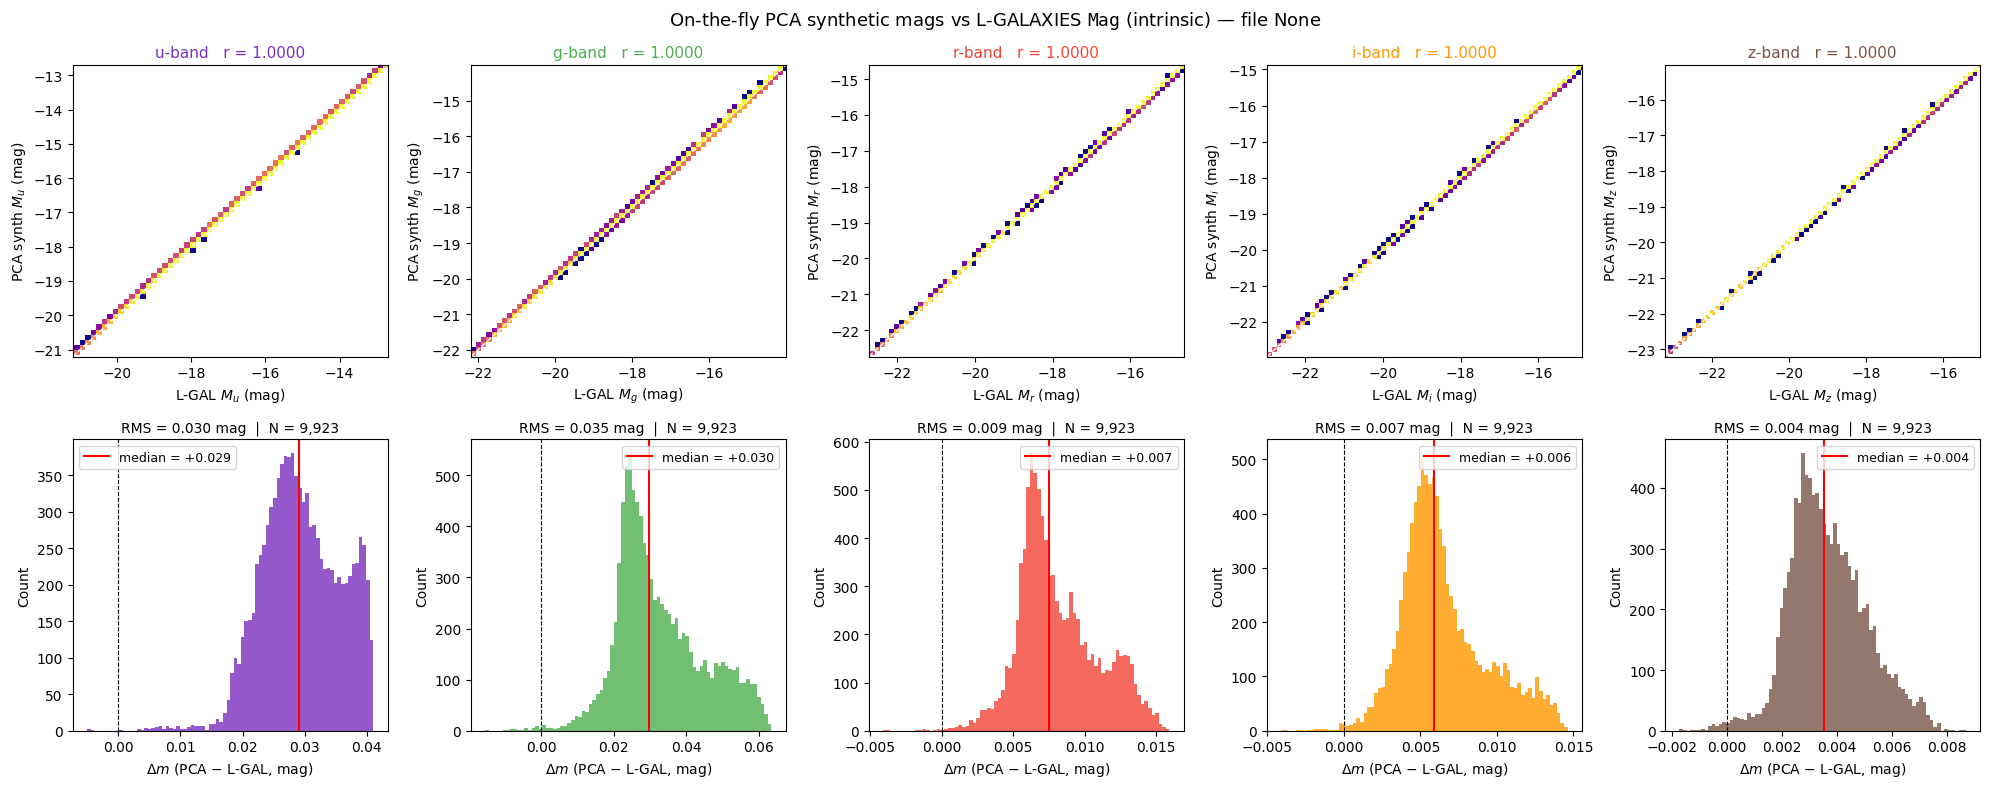

In [11]:
lgal_mag = gals_m['Mag']   # (N, 5) intrinsic SDSS ugriz AB mag — direct from binary

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(f'On-the-fly PCA synthetic mags vs L-GALAXIES $\\mathtt{{Mag}}$ (intrinsic) — file {FILE_NR}',
             fontsize=13)

for col, b in enumerate(BANDS):
    bi     = BAND_IDX[b]
    synth  = synth_mags[b]
    stored = lgal_mag[:, bi]
    valid  = np.isfinite(synth) & (stored < 90.0)
    x, y   = synth[valid], stored[valid]
    delta  = x - y

    ax = axes[0, col]
    ax.hist2d(y, x, bins=80, cmin=1, cmap='plasma',
              norm=LogNorm(vmin=1, vmax=max(10, len(x)//100)))
    xlim = (np.percentile(y, 0.5), np.percentile(y, 99.5))
    ax.plot(xlim, xlim, 'w--', lw=1.0, label='1:1')
    ax.set_xlim(*xlim); ax.set_ylim(*xlim)
    ax.set_xlabel(f'L-GAL $M_{b}$ (mag)', fontsize=10)
    ax.set_ylabel(f'PCA synth $M_{b}$ (mag)', fontsize=10)
    r, _ = stats.pearsonr(x, y)
    ax.set_title(f'{b}-band   r = {r:.4f}', color=BAND_COLORS[b], fontsize=11)

    ax2 = axes[1, col]
    ax2.hist(delta, bins=80, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
    ax2.axvline(0, color='k', lw=0.8, ls='--')
    ax2.axvline(np.median(delta), color='red', lw=1.5,
                label=f'median = {np.median(delta):+.3f}')
    ax2.set_xlabel(r'$\Delta m$ (PCA $-$ L-GAL, mag)', fontsize=10)
    ax2.set_ylabel('Count', fontsize=10)
    ax2.legend(fontsize=9)
    rms = np.sqrt(np.mean(delta**2))
    ax2.set_title(f'RMS = {rms:.3f} mag  |  N = {valid.sum():,}', fontsize=10)

plt.tight_layout()
plt.savefig(GALSPECTRA_ROOT / 'data' / f'pca_otf_vs_lgal_intrinsic_file{FILE_NR}.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 8. On-the-fly mags vs post-processing `synth_mag_*`

Both use the same PCA model and the same galaxy SFH data, so the agreement should be
near-perfect (differences arise only from float32 → float64 rounding in the C code).

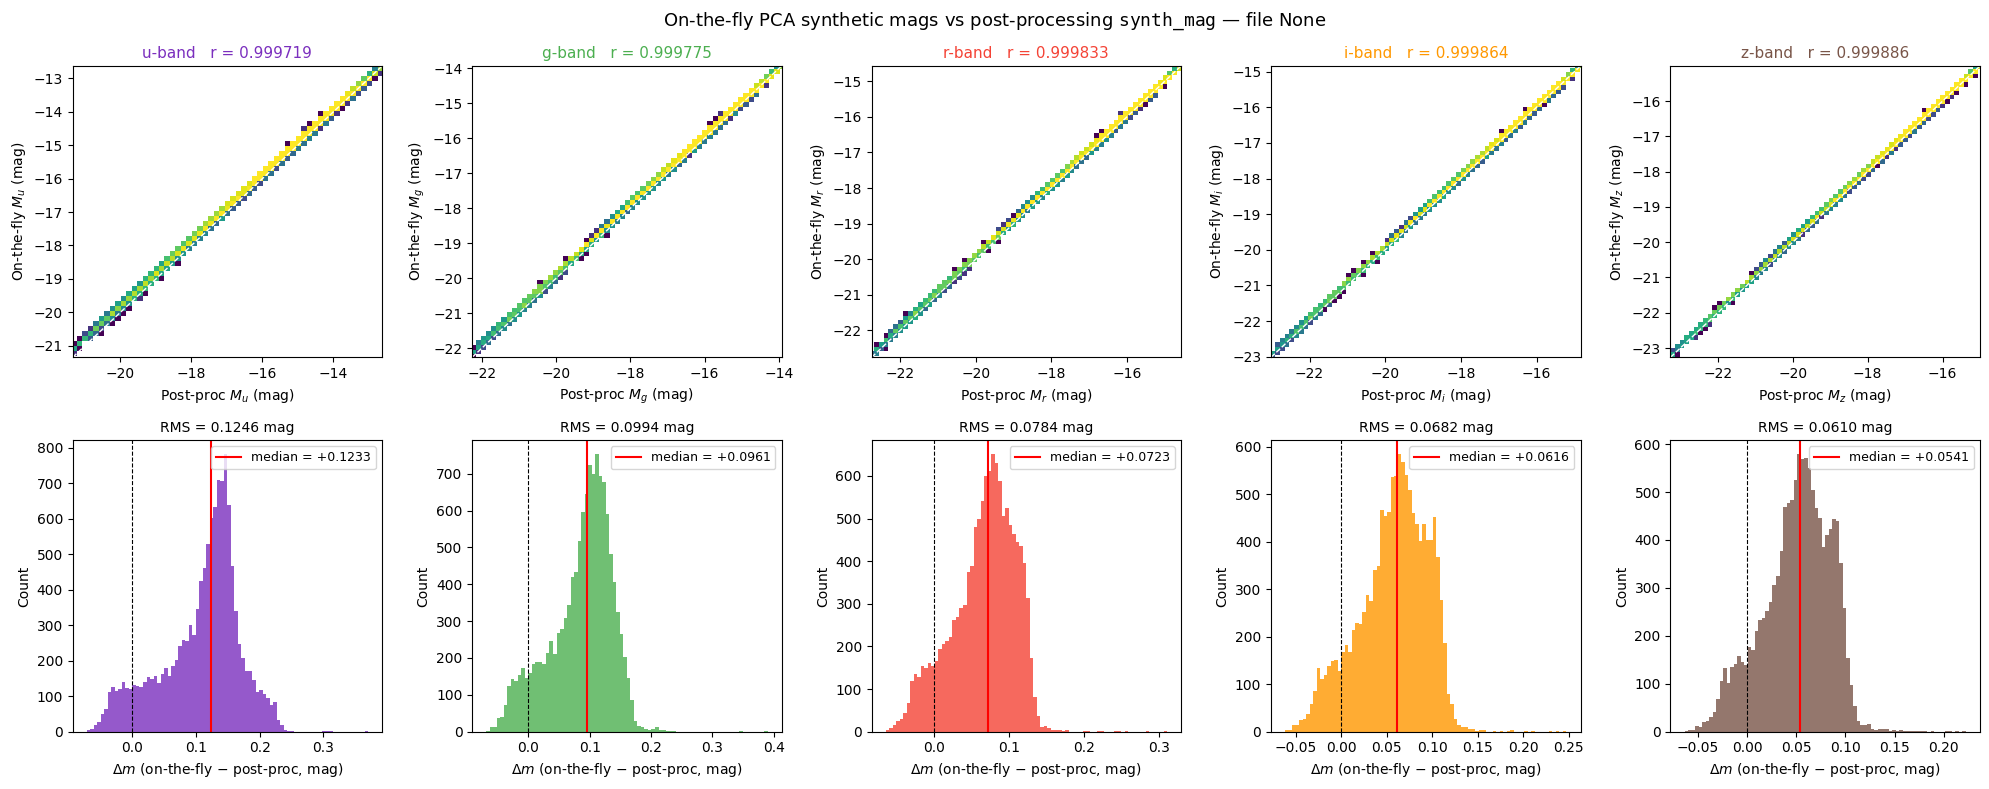

In [12]:
if N_PP == 0:
    print('Skipping: no post-processing matches for this file.')
else:
    synth_pp = {b: synth_mags[b][matched_i_pp] for b in BANDS}  # on-the-fly for matched gals

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f'On-the-fly PCA synthetic mags vs post-processing $\\mathtt{{synth\\_mag}}$ — file {FILE_NR}',
                 fontsize=13)

    for col, b in enumerate(BANDS):
        synth  = synth_pp[b]
        stored = pp_synth_m[b]
        valid  = np.isfinite(synth) & np.isfinite(stored) & (stored < 90.0)
        x, y   = synth[valid], stored[valid]
        delta  = x - y

        ax = axes[0, col]
        ax.hist2d(y, x, bins=80, cmin=1, cmap='viridis',
                  norm=LogNorm(vmin=1, vmax=max(10, len(x)//100)))
        xlim = (np.percentile(y, 0.5), np.percentile(y, 99.5))
        ax.plot(xlim, xlim, 'w--', lw=1.0)
        ax.set_xlim(*xlim); ax.set_ylim(*xlim)
        ax.set_xlabel(f'Post-proc $M_{b}$ (mag)', fontsize=10)
        ax.set_ylabel(f'On-the-fly $M_{b}$ (mag)', fontsize=10)
        r, _ = stats.pearsonr(x, y)
        ax.set_title(f'{b}-band   r = {r:.6f}', color=BAND_COLORS[b], fontsize=11)

        ax2 = axes[1, col]
        ax2.hist(delta, bins=80, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
        ax2.axvline(0, color='k', lw=0.8, ls='--')
        ax2.axvline(np.median(delta), color='red', lw=1.5,
                    label=f'median = {np.median(delta):+.4f}')
        ax2.set_xlabel(r'$\Delta m$ (on-the-fly $-$ post-proc, mag)', fontsize=10)
        ax2.set_ylabel('Count', fontsize=10)
        ax2.legend(fontsize=9)
        rms = np.sqrt(np.mean(delta**2))
        ax2.set_title(f'RMS = {rms:.4f} mag', fontsize=10)

    plt.tight_layout()
    plt.savefig(GALSPECTRA_ROOT / 'data' / f'pca_otf_vs_postproc_file{FILE_NR}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


## 9. Summary statistics

In [13]:
synth_pp = {b: synth_mags[b][matched_i_pp] for b in BANDS} if N_PP > 0 else {}

print(f'{"Band":<6}  {"":=<58}')
print(f'{"Band":<6}  {"On-the-fly vs L-GAL Mag":^28}  {"On-the-fly vs post-proc":^28}')
print(f'{"":<6}  {"median Δ":>10} {"RMS":>8} {"r":>8}  {"median Δ":>10} {"RMS":>8} {"r":>8}')
print(f'{"":<6}  {"-"*28}  {"-"*28}')

for b in BANDS:
    bi    = BAND_IDX[b]
    synth = synth_mags[b]
    lgal  = gals_m['Mag'][:, bi]

    vl = np.isfinite(synth) & (lgal < 90.0)
    dl = synth[vl] - lgal[vl]
    r_l, _ = stats.pearsonr(synth[vl], lgal[vl])

    if N_PP > 0:
        sp   = synth_pp[b]
        pp_s = pp_synth_m[b]
        vp   = np.isfinite(sp) & np.isfinite(pp_s)
        dp   = sp[vp] - pp_s[vp]
        r_p, _ = stats.pearsonr(sp[vp], pp_s[vp])
        pp_str = f'{np.median(dp):>+10.4f} {np.sqrt(np.mean(dp**2)):>8.4f} {r_p:>8.6f}'
    else:
        pp_str = f'{"(no match)":>10} {"--":>8} {"--":>8}'

    print(f'{b:<6}  {np.median(dl):>+10.3f} {np.sqrt(np.mean(dl**2)):>8.3f} {r_l:>8.4f}  {pp_str}')

print(f'{"":<6}  {"":-<58}')
print('\nNotes:')
print('  vs L-GAL Mag: residuals reflect PCA reconstruction accuracy + filter differences')
print('  vs post-proc: near-zero means C on-the-fly ≈ Python post-processing (numerical check)')


Band    ==========================================================
Band      On-the-fly vs L-GAL Mag       On-the-fly vs post-proc   
          median Δ      RMS        r    median Δ      RMS        r
        ----------------------------  ----------------------------
u           +0.029    0.030   1.0000     +0.1233   0.1246 0.999719
g           +0.030    0.035   1.0000     +0.0961   0.0994 0.999775
r           +0.007    0.009   1.0000     +0.0723   0.0784 0.999833
i           +0.006    0.007   1.0000     +0.0616   0.0682 0.999864
z           +0.004    0.004   1.0000     +0.0541   0.0610 0.999886
        ----------------------------------------------------------

Notes:
  vs L-GAL Mag: residuals reflect PCA reconstruction accuracy + filter differences
  vs post-proc: near-zero means C on-the-fly ≈ Python post-processing (numerical check)


## 10. Colour–magnitude and colour–colour diagnostics

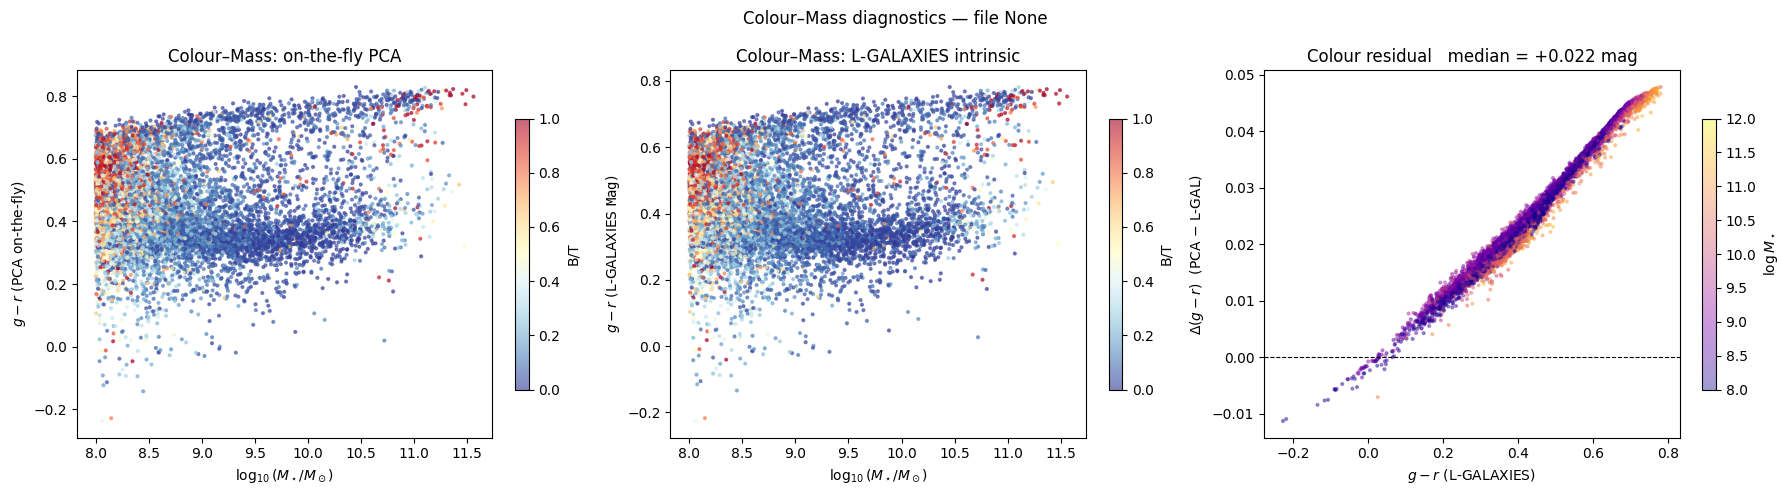

In [14]:
# stellar_mass and bulge_mass are pre-converted to Msun (defined in cell 4)
log_mstar  = np.log10(stellar_mass + 1e-10)
bt         = bulge_mass / (stellar_mass + 1e-10)
lgal_mag   = gals_m['Mag']   # (N, 5) from binary

gr_otf  = synth_mags['g'] - synth_mags['r']
ur_otf  = synth_mags['u'] - synth_mags['r']
gr_lgal = lgal_mag[:, 1] - lgal_mag[:, 2]
ur_lgal = lgal_mag[:, 0] - lgal_mag[:, 2]

valid_both = np.isfinite(gr_otf) & (lgal_mag[:, 2] < 90.)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Colour–Mass diagnostics — file {FILE_NR}', fontsize=12)

ax = axes[0]
sc = ax.scatter(log_mstar[valid_both], gr_otf[valid_both],
                c=bt[valid_both], cmap='RdYlBu_r', s=4, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='B/T', fraction=0.03)
ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
ax.set_ylabel(r'$g - r$ (PCA on-the-fly)')
ax.set_title('Colour–Mass: on-the-fly PCA')

ax = axes[1]
sc = ax.scatter(log_mstar[valid_both], gr_lgal[valid_both],
                c=bt[valid_both], cmap='RdYlBu_r', s=4, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='B/T', fraction=0.03)
ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
ax.set_ylabel(r'$g - r$ (L-GALAXIES $\mathtt{Mag}$)')
ax.set_title('Colour–Mass: L-GALAXIES intrinsic')

ax = axes[2]
d_gr = gr_otf[valid_both] - gr_lgal[valid_both]
sc = ax.scatter(gr_lgal[valid_both], d_gr,
                c=log_mstar[valid_both], cmap='plasma', s=4, alpha=0.4,
                vmin=8, vmax=12)
plt.colorbar(sc, ax=ax, label=r'$\log M_\star$', fraction=0.03)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel(r'$g - r$ (L-GALAXIES)')
ax.set_ylabel(r'$\Delta(g-r)$  (PCA $-$ L-GAL)')
ax.set_title(f'Colour residual   median = {np.median(d_gr):+.3f} mag')

plt.tight_layout()
plt.show()


## 11. Interactive SED explorer

Select any galaxy from the matched sample.  The plot shows:
- **Black solid line** — SED reconstructed from the on-the-fly PCA coefficients
- **Shaded regions** — SDSS *ugriz* filter bandpasses (scaled for visibility)
- **Markers** — synthetic AB magnitudes (on-the-fly ✦) and L-GALAXIES stored `Mag` (◆)

> **Tip:** A slider value of 0 is the first matched galaxy; use the galaxy properties panel to find interesting objects.

In [15]:
from ipywidgets import interact, IntSlider, Checkbox, Layout

def plot_galaxy_sed(galaxy_idx=0, log_scale=True, show_residuals=True):
    """Plot on-the-fly reconstructed SED for the given galaxy index."""
    k     = galaxy_idx
    sed   = seds[k]

    # Galaxy properties — from binary (masses already in Msun via stellar_mass/bulge_mass)
    log_m  = float(np.log10(stellar_mass[k] + 1e-30))
    sfr    = float(gals_m[k]['Sfr'])
    bt_val = float(bulge_mass[k] / (stellar_mass[k] + 1e-10))
    gr_val = float(synth_mags['g'][k] - synth_mags['r'][k])

    otf_m  = {b: float(synth_mags[b][k]) for b in BANDS}
    lgal_m = {b: float(gals_m[k]['Mag'][BAND_IDX[b]]) for b in BANDS}

    # Post-proc mags: only available for galaxies matched to the full sample
    pp_pos = _pp_lookup.get(k, None)
    pp_m   = {b: float(pp_synth_m[b][pp_pos]) if pp_pos is not None else np.nan
              for b in BANDS}

    # ── Layout ────────────────────────────────────────────────────────────
    if show_residuals:
        fig = plt.figure(figsize=(16, 6))
        gs  = gridspec.GridSpec(1, 2, width_ratios=[2, 1])
        ax_sed = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1])
    else:
        fig, ax_sed = plt.subplots(figsize=(11, 6))
        ax_res = None

    # ── SED panel ─────────────────────────────────────────────────────────
    if log_scale:
        sed_plot = np.maximum(sed, 1e-40)
        ax_sed.semilogy(pca_wave, sed_plot, color='black', lw=2.0,
                        label='On-the-fly PCA SED', zorder=5)
        sed_peak = sed_plot.max()
    else:
        ax_sed.plot(pca_wave, sed, color='black', lw=2.0,
                    label='On-the-fly PCA SED', zorder=5)
        sed_peak = sed.max()

    for band, (wf, tf) in filters.items():
        tf_interp = np.interp(pca_wave, wf, tf, left=0., right=0.)
        peak_idx  = int(np.argmax(tf_interp))
        scale     = sed_peak * 0.20
        if log_scale:
            ax_sed.fill_between(pca_wave, 1e-40,
                                np.maximum(tf_interp * scale, 1e-40),
                                alpha=0.12, color=BAND_COLORS[band])
        else:
            ax_sed.fill_between(pca_wave, 0, tf_interp * scale,
                                alpha=0.12, color=BAND_COLORS[band])
        ax_sed.text(pca_wave[peak_idx], tf_interp[peak_idx] * scale * 1.05,
                    band, ha='center', va='bottom',
                    fontsize=9, color=BAND_COLORS[band], fontweight='bold')

    for band in BANDS:
        leff  = BAND_LEFF[band]
        f_ref = float(np.interp(leff, pca_wave, sed))
        if f_ref > 0 and np.isfinite(otf_m[band]):
            ax_sed.scatter([leff], [f_ref], marker='*', s=150,
                           color=BAND_COLORS[band], zorder=8)

    ax_sed.set_xlim(pca_wave[0], pca_wave[-1])
    ax_sed.set_xlabel('Wavelength (Å)', fontsize=12)
    ax_sed.set_ylabel(r'$f_\lambda$  (erg s$^{-1}$ Å$^{-1}$ cm$^{-2}$)', fontsize=12)
    ax_sed.set_title(
        f'Galaxy #{k} (file {FILE_NR})  |  '
        f'$\\log M_\\star = {log_m:.2f}$  |  '
        f'$g-r = {gr_val:.3f}$  |  '
        f'$B/T = {bt_val:.2f}$  |  '
        f'SFR = {sfr:.2f} M☉/yr',
        fontsize=11)
    ax_sed.legend(fontsize=10, loc='upper right')

    # ── Residual bar chart ─────────────────────────────────────────────────
    if ax_res is not None:
        x      = np.arange(len(BANDS))
        w      = 0.35
        d_lgal = [otf_m[b] - lgal_m[b] if lgal_m[b] < 90. else 0. for b in BANDS]
        d_pp   = [otf_m[b] - pp_m[b]   if np.isfinite(pp_m[b]) else 0. for b in BANDS]

        ax_res.bar(x - w/2, d_lgal, w, color='steelblue', alpha=0.85,
                   label='OTF − L-GAL Mag')
        ax_res.bar(x + w/2, d_pp,   w, color='tomato',    alpha=0.85,
                   label='OTF − post-proc')
        ax_res.axhline(0, color='k', lw=0.8)
        ax_res.set_xticks(x)
        ax_res.set_xticklabels(BANDS, fontsize=11)
        ax_res.set_xlabel('SDSS band', fontsize=11)
        ax_res.set_ylabel(r'$\Delta m$ (mag)', fontsize=11)
        ax_res.set_ylim(-0.5, 0.5)
        ax_res.set_title('Magnitude residuals', fontsize=11)
        ax_res.legend(fontsize=9)
        ax_res.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'{"Band":<5} {"OTF":>8} {"L-GAL Mag":>10} {"Δ(OTF-LG)":>10} | '
          f'{"post-proc":>10} {"Δ(OTF-PP)":>10}')
    print('─' * 62)
    for b in BANDS:
        lgal_str = f'{lgal_m[b]:>10.3f}' if lgal_m[b] < 90. else f'{"(n/a)":>10}'
        dlg_str  = f'{otf_m[b]-lgal_m[b]:>+10.3f}' if lgal_m[b] < 90. else f'{"--":>10}'
        pp_str   = f'{pp_m[b]:>10.3f}' if np.isfinite(pp_m[b]) else f'{"(n/a)":>10}'
        dpp_str  = f'{otf_m[b]-pp_m[b]:>+10.4f}' if np.isfinite(pp_m[b]) else f'{"--":>10}'
        print(f'{b:<5} {otf_m[b]:>8.3f} {lgal_str} {dlg_str} | {pp_str} {dpp_str}')


interact(
    plot_galaxy_sed,
    galaxy_idx=IntSlider(min=0, max=N_MATCH - 1, step=1, value=0,
                         description='Galaxy index:',
                         style={'description_width': 'initial'},
                         layout=Layout(width='600px')),
    log_scale=Checkbox(value=True,  description='Log y-axis'),
    show_residuals=Checkbox(value=True, description='Show residuals'),
);


interactive(children=(IntSlider(value=0, description='Galaxy index:', layout=Layout(width='600px'), max=12600,…

## 12. Pick interesting galaxies interactively

Helper to find representative galaxy types within the matched sample, then pass their index to the explorer above.

In [16]:
# stellar_mass and bulge_mass pre-converted to Msun (from cell 4)
log_m   = np.log10(stellar_mass + 1e-30)
sfr_m   = gals_m['Sfr'].astype(float)
bt_m    = bulge_mass / (stellar_mass + 1e-10)
gr_m    = synth_mags['g'] - synth_mags['r']
ssfr_m  = sfr_m / (stellar_mass + 1e-30)
valid_m = np.isfinite(gr_m)

def pick_idx(mask, sort_key=None, pick='median'):
    idx = np.where(mask & valid_m)[0]
    if len(idx) == 0:
        return None
    if sort_key is not None:
        idx = idx[np.argsort(sort_key[idx])]
    return int(idx[-1] if pick == 'max' else idx[len(idx) // 2])

examples = {
    'Massive red elliptical' : pick_idx(bt_m > 0.8, sort_key=log_m, pick='max'),
    'Blue star-forming disk'  : pick_idx((bt_m < 0.2) & (gr_m < 0.3) & (log_m > 9.0)),
    'Green valley'            : pick_idx((gr_m > 0.4) & (gr_m < 0.5) & (log_m > 9.5)),
    'Highest sSFR'            : pick_idx((bt_m < 0.3) & (log_m > 8.5), sort_key=ssfr_m, pick='max'),
    'Lowest mass (above cut)' : pick_idx(valid_m, sort_key=-log_m, pick='max'),
}

print(f'{"Type":<28} {"Idx":>6} {"logM*":>6} {"g-r":>6} {"B/T":>5} {"SFR":>9}')
print('-' * 65)
for name, idx in examples.items():
    if idx is None:
        print(f'{name:<28}  not found in file {FILE_NR}')
        continue
    print(f'{name:<28} {idx:>6d} {log_m[idx]:>6.2f} {gr_m[idx]:>6.3f} '
          f'{bt_m[idx]:>5.2f} {sfr_m[idx]:>9.3f}')
print('\nPass any index above to the galaxy_idx slider in Section 11.')


Type                            Idx  logM*    g-r   B/T       SFR
-----------------------------------------------------------------
Massive red elliptical         9892  11.56  0.799  1.00     0.145
Blue star-forming disk         6429   9.79  0.212  0.02     2.235
Green valley                   5580  10.31  0.415  0.02     2.154
Highest sSFR                  10874   8.57 -0.004  0.08     0.796
Lowest mass (above cut)        6771   8.00  0.471  0.92     0.003

Pass any index above to the galaxy_idx slider in Section 11.


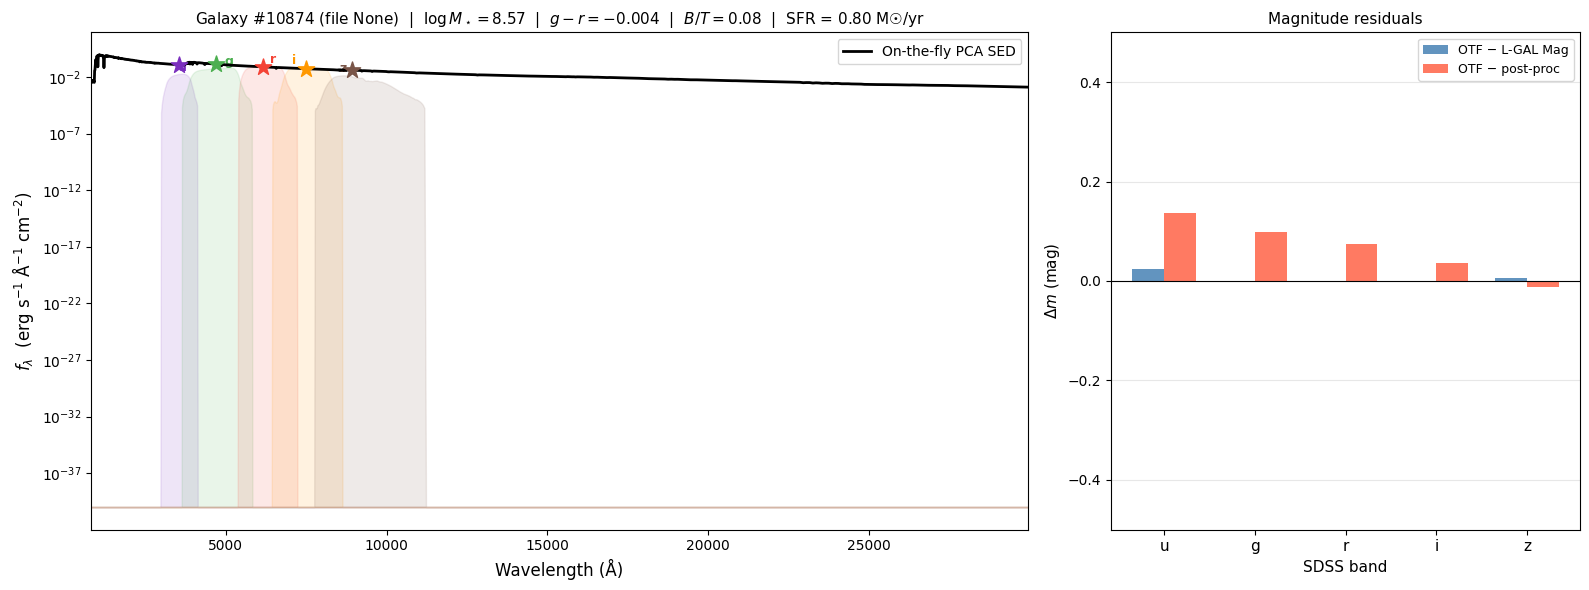

Band       OTF  L-GAL Mag  Δ(OTF-LG) |  post-proc  Δ(OTF-PP)
──────────────────────────────────────────────────────────────
u      -17.987    -18.011     +0.024 |    -18.124    +0.1369
g      -18.626    -18.625     -0.001 |    -18.724    +0.0985
r      -18.622    -18.623     +0.001 |    -18.696    +0.0736
i      -18.642    -18.643     +0.001 |    -18.677    +0.0353
z      -18.652    -18.657     +0.006 |    -18.639    -0.0124


In [17]:
plot_galaxy_sed(galaxy_idx=min(10874, N_MATCH-1), log_scale=True, show_residuals=True)